# TP1 – Classification par kppv

**Nom : DIALLO**  
**Prénom : Mamadou djouldé**  
**Cursus : M1 Syscom**

---

# Objectif :

Dans ce TP, nous allons utiliser une partie de la base de visages “Labeled Faces in the Wild” 
provenant de http://vis-www.cs.umass.edu/lfw/. Cette base contient 5749 personnes et 13233 
images de taille 62 x 47 pixels. Certaines personnes ne sont représentées qu’une seule fois tandis 
que d’autres sont représentées très souvent (plus de 80 fois). Nous utiliserons ici seulement 7 
personnes représentées 1288 fois.

---

## I. Chargement des données

Ici, je commence par charger la base d’images, puis j’utilise deux fonctions pour mieux la comprendre : plotGallery() pour afficher un aperçu des visages et plotHistoClasses() pour voir la répartition des classes

In [7]:
# Import des bibliothèques nécessaires
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
from skimage.color import rgb2gray
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

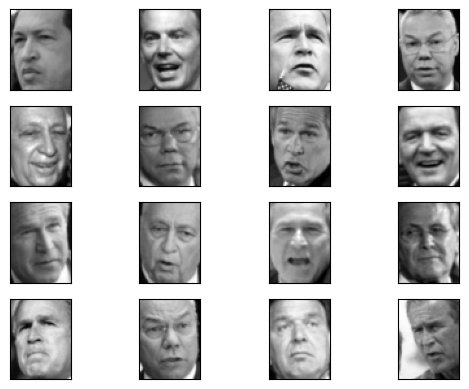

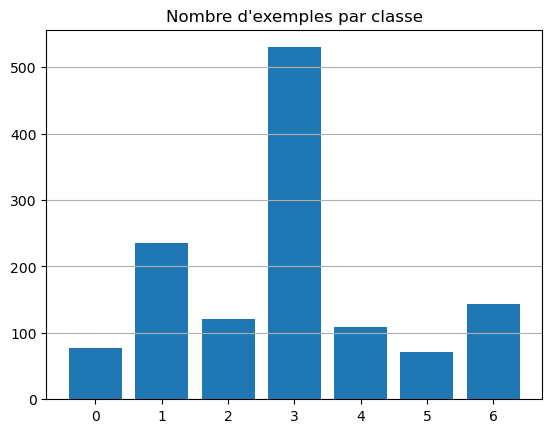

In [8]:
def plotGallery(images, n=16, title=None):
    # Affiche les n premières images contenues dans images
    # images est de taille Nb image*Ny*Nx
    n = min(n, images.shape[0])
    nSubplots = int(np.ceil(np.sqrt(n)))
    fig, axs = plt.subplots(nSubplots, nSubplots)
    for i in range(n):
        axs[i // nSubplots, i % nSubplots].imshow(images[i], cmap=plt.cm.gray)
        axs[i // nSubplots, i % nSubplots].set_xticks([])
        axs[i // nSubplots, i % nSubplots].set_yticks([])
    if title:
        plt.suptitle(title)
    plt.show()

def plotHistoClasses(lbls):
    # Affiche le nombre d'exemples par classe
    nLbls = np.array([[i, np.where(lbls == i)[0].shape[0]] for i in np.unique(lbls)])
    plt.figure()
    plt.bar(nLbls[:, 0], nLbls[:, 1])
    plt.title("Nombre d'exemples par classe")
    plt.grid(axis='y')
    plt.show()

# I.a. Chargement de la base de données (images, labels, noms de classes)
[X, y, name]=np.load("TP1.npy",allow_pickle=True)

# Affichage des premières images pour visualiser la base
plotGallery(X)

# Affichage de la répartition des classes dans la base
plotHistoClasses(y)



### a. Charger les données 
À partir des variables fournies (x, y et name), nous déterminons la taille des images, le nombre total d’images ainsi que le nombre de classes présentes dans la base.
#### Reponses aux Questions  


In [9]:
# Affichage des informations principales
print("Taille d'une image :", X[0].shape)
print("Nombre d'images :", X.shape[0])
print("Nombre de classes :", len(name))

Taille d'une image : (62, 47)
Nombre d'images : 1288
Nombre de classes : 7


##### Explication 

La base contient des images de visages de différentes personnes.
En regardant X, je me suis rendu compte de quelques détails :

Chaque image fait 62×47 pixels, ce qu’on voit avec X[0].shape.

Il y a 1288 images au total, vérifiable avec X.shape[0].

La base comporte 7 classes, correspondant aux différentes personnes, qu’on obtient avec len(name).

Pour résumer, X contient les images elles-mêmes (les features), y contient les labels associés à chaque image, et name regroupe les noms des classes, c’est-à-dire l’identité des personnes.

 Nous identifions les 16 personnes affichées à partir de la variable name. Ensuite, nous vérifions si les classes sont équiprobables en observant la répartition des exemples. Enfin, nous déterminons le nombre d’exemples par classe à l’aide des labels y.

In [10]:
# Affichage des noms des 16 premières personnes affichées
print("Noms des 16 premières personnes :", [str(name[yi]) for yi in y[:16]])

# Vérification de l'équiprobabilité des classes (visuelle via l'histogramme)
# (La réponse sera donnée dans la section réponse)

# Affichage du nombre d'exemples par classe 
nb_exemples_par_classe = [int(np.sum(y == i)) for i in range(len(name))]
print("Nombre d'exemples par classe :", nb_exemples_par_classe)

""" Les 16 premières personnes affichées sont : 
#   'Hugo Chavez', 'Tony Blair', 'George W Bush', 'Colin Powell', 'Ariel Sharon'
#   'Colin Powell', 'George W Bush', 'Gerhard Schroeder', 'George W Bush', 'Ariel Sharon', 
#   'George W Bush', 'Donald Rumsfeld', 'George W Bush', 'Colin Powell', 'Gerhard Schroeder', 'George W Bush'
#   Ceci est obtenu en mappant les 16 premiers labels y aux noms correspondants dans name.
"""

""" Les classes ne sont pas équiprobables :
    L'histogramme montre que certaines classes ont plus d'exemples que d'autres.
"""

""" Nombre d'exemples par classe : [77, 236, 121, 530, 109, 71, 144] 
    Cela indique que la classe 3 (index 3) a le plus d'exemples (530), 
    tandis que la classe 5 (index 5) en a le moins (71).
    Ces informations sont obtenues en comptant les occurrences de chaque label dans y."""

Noms des 16 premières personnes : ['Hugo Chavez', 'Tony Blair', 'George W Bush', 'Colin Powell', 'Ariel Sharon', 'Colin Powell', 'George W Bush', 'Gerhard Schroeder', 'George W Bush', 'Ariel Sharon', 'George W Bush', 'Donald Rumsfeld', 'George W Bush', 'Colin Powell', 'Gerhard Schroeder', 'George W Bush']
Nombre d'exemples par classe : [77, 236, 121, 530, 109, 71, 144]


" Nombre d'exemples par classe : [77, 236, 121, 530, 109, 71, 144] \n    Cela indique que la classe 3 (index 3) a le plus d'exemples (530), \n    tandis que la classe 5 (index 5) en a le moins (71).\n    Ces informations sont obtenues en comptant les occurrences de chaque label dans y."

##### Explication 
En associant les premiers labels aux classes correspondantes, j’ai pu retrouver l’identité des 16 premières personnes affichées.

L’histogramme montre que les classes ne sont pas toutes équilibrées : certaines ont beaucoup plus d’images que d’autres.

En comptant le nombre d’exemples pour chaque classe, j’obtiens la répartition suivante : [77, 236, 121, 530, 109, 71, 144]. La classe 3 a le plus d’images avec 530, tandis que la classe 5 en a le moins, soit 71.


### b. Partitionnement de la base d’apprentissage 
Nous partitionnons la base de données en une base d’apprentissage et une base de test, en mettant 25 % des images dans la base de test.
Pour garantir la reproductibilité des résultats, nous utilisons la fonction train_test_split() avec random_state fixé aux trois derniers chiffres de mon numéro d’étudiant, soit 052.
Cette étape nous permet d’obtenir les variables X_train, X_test, y_train et y_test, qui serviront respectivement pour l’entraînement et l’évaluation du modèle.

#### Reponses
Nous déterminons le nombre d’images dans les bases d’apprentissage et de test, ainsi que les dimensions des quatre variables X_train, X_test, y_train et y_test.

In [11]:
# I.b. Partitionnement de la base d’apprentissage
# Affichage des tailles des ensembles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=52, stratify=y)

# Affichage du nombre d'images dans chaque ensemble
print("Nombre d'images en apprentissage :", X_train.shape[0])
print("Nombre d'images en test :", X_test.shape[0])

# Affichage des dimensions des variables
print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test :", y_test.shape)



Nombre d'images en apprentissage : 966
Nombre d'images en test : 322
Dimensions de X_train : (966, 62, 47)
Dimensions de X_test : (322, 62, 47)
Dimensions de y_train : (966,)
Dimensions de y_test : (322,)


##### Explication
Après le partitionnement de la base :

La base d’apprentissage contient 966 images, et la base de test 322 images.

Les dimensions des variables sont :

X_train : (966, 62, 47)

X_test : (322, 62, 47)

y_train : (966,)

y_test : (322,)

Ces informations viennent de l’utilisation de train_test_split de sklearn avec test_size=0.25, ce qui correspond à 25 % des données pour le test. Le paramètre stratify=y permet de garder la même répartition des classes dans les deux ensembles

## II. Prétraitement des données
### a. Redimensionnement des données
Pour effectuer une classification par K plus proches voisins (kppv), nous représentons chaque image sous forme d’un vecteur de caractéristiques de dimension 𝑛 = 2914 grâce à un codage rétinien.
Nous redimensionnons ensuite X_train et X_test avec np.reshape() afin qu’ils aient pour dimension 𝑁 × 𝑛, où 𝑁 correspond au nombre d’exemples dans chaque ensemble.

#### Reponse

In [12]:
# II Prétraitement des données
# II.a. Redimensionnement des données pour le codage rétinien (kppv)

# Chaque image doit être représentée par un vecteur de 2914 caractéristiques (62*47)
# On redimensionne X_train et X_test pour obtenir (N, 2914) où N est le nombre d'exemples
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("\nAprès redimensionnement :")
print("Dimensions de X_train :", X_train.shape)  # (Nb images train, 2914)
print("Dimensions de X_test :", X_test.shape)    # (Nb images test, 2914)




Après redimensionnement :
Dimensions de X_train : (966, 2914)
Dimensions de X_test : (322, 2914)


##### Explication
Après redimensionnement, chaque image de X_train et X_test est représentée par un vecteur de 2914 caractéristiques.
Les dimensions deviennent :

X_train : (966, 2914)

X_test : (322, 2914)

Ce résultat est obtenu en utilisant X_train.reshape(X_train.shape[0], 2914) et X_test.reshape(X_test.shape[0], 2914).

### b. Mise en forme des données pour la classification 
Nous mettons en forme les données d’apprentissage et de test à l’aide de la classe StandardScaler.
La moyenne et l’écart-type de chaque dimension sont estimés uniquement à partir des données d’apprentissage, puis ces valeurs sont utilisées pour transformer à la fois X_train et X_test.
Cette étape garantit que la normalisation est calculée à partir de l’ensemble d’apprentissage, tout en appliquant la même mise en forme aux données de test.

#### Reponse

In [13]:
print("\nMise en forme des données :")
# Utilisation de StandardScaler pour centrer et réduire les données
# On ajuste le scaler uniquement sur X_train (fit), puis on transforme X_train et X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform sur train
X_test_scaled = scaler.transform(X_test)        # transform sur test uniquement

# Affichage de la moyenne et de l'écart-type pour vérifier la normalisation
print("Moyenne de X_train_scaled : {:.2f}, écart-type : {:.2f}".format(np.mean(X_train_scaled), np.std(X_train_scaled)))
print("Moyenne de X_test_scaled : {:.2f}, écart-type : {:.2f}".format(np.mean(X_test_scaled), np.std(X_test_scaled)))


Mise en forme des données :
Moyenne de X_train_scaled : 0.00, écart-type : 1.00
Moyenne de X_test_scaled : -0.01, écart-type : 0.99


##### Explication 
La mise en forme des données consiste à centrer et réduire chaque caractéristique (chaque colonne du jeu de données).

On soustrait la moyenne et on divise par l'écart-type calculés sur les données d'apprentissage (StandardScaler).

Ainsi, chaque dimension a une moyenne nulle et un écart-type égal à 1 sur l'ensemble d'apprentissage.
Cette transformation permet d'éviter que certaines caractéristiques dominent les autres à cause de leur échelle.
On applique ensuite la même transformation (moyenne et écart-type du train) sur les données de test.

## III Classification par les KPPV 
### c. Classifieur 1PPV
Dans cette partie, nous définissons un classifieur K plus proches voisins avec K=1 en utilisant la classe KNeighborsClassifier().
Nous utilisons la distance euclidienne pour mesurer la proximité entre les exemples.

Ensuite, nous réalisons la classification des exemples de test avec la méthode predict().
Pour évaluer les performances du classifieur, nous affichons la matrice de confusion à l’aide de confusion_matrix() et estimons le taux de reconnaissance (accuracy) à partir de cette matrice.
Enfin, nous vérifions que ce taux correspond à celui retourné directement par la fonction accuracy_score().

#### Reponse 

In [14]:
print("\nClassification par le classifieur 1PPV :") 
# Définition du classifieur 1PPV (k=1, distance euclidienne par défaut)
knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn.fit(X_train_scaled, y_train)

# Prédiction sur les exemples de test
y_pred = knn.predict(X_test_scaled)

# Affichage de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion :\n", cm)

# Estimation du taux de reconnaissance (accuracy)
taux_reconnaissance = np.trace(cm) / np.sum(cm)
print("Taux de reconnaissance (calculé à partir de la matrice) : {:.2f}%".format(100 * taux_reconnaissance))

# Vérification avec accuracy_score
acc_score = accuracy_score(y_test, y_pred)
print("Taux de reconnaissance (accuracy_score) : {:.2f}%".format(100 * acc_score))


Classification par le classifieur 1PPV :

Matrice de confusion :
 [[  8   2   0   5   1   2   1]
 [  2  41   5   9   1   0   1]
 [  2   5  12   8   0   1   2]
 [  3   6   9 101   3   5   6]
 [  0   2   2   6   9   1   7]
 [  0   1   0   2   3  12   0]
 [  2   0   4   7   3   1  19]]
Taux de reconnaissance (calculé à partir de la matrice) : 62.73%
Taux de reconnaissance (accuracy_score) : 62.73%


##### Explication
- La matrice de confusion représente, pour chaque classe réelle (ligne), la répartition des prédictions faites par le classifieur (colonnes).
    - L’élément (i, j) indique le nombre d’images de la classe réelle i prédites comme appartenant à la classe j.
- La somme de tous les éléments de la matrice de confusion correspond au nombre total d’images de la base de test (ici : 322).
- La somme de chaque ligne donne le nombre d’images de la classe réelle correspondante dans la base de test.
- Les classes ne sont pas équilibrées dans la base de test : certaines lignes ont des sommes bien plus grandes que d’autres (par exemple, la classe 3 a 133 images, la classe 5 seulement 18).


### d. Classifieur KPPV
Soit à faire varier le K des KPPV et tracez l’évolution du taux de reconnaissance en fonction de K.

#### Reponse

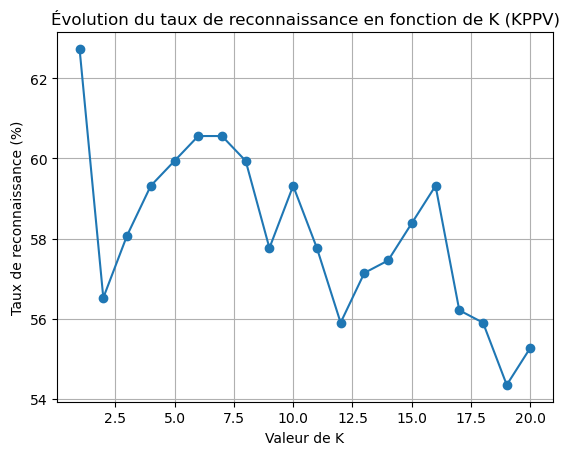

In [15]:
# Évolution du taux de reconnaissance en fonction de K
K_values = range(1, 21)  # On teste K de 1 à 20
accuracies = []
for k in K_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_k.fit(X_train_scaled, y_train)
    y_pred_k = knn_k.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)

# Tracé de l'évolution du taux de reconnaissance
plt.figure()
plt.plot(K_values, [100*a for a in accuracies], marker='o')
plt.xlabel('Valeur de K')
plt.ylabel('Taux de reconnaissance (%)')
plt.title('Évolution du taux de reconnaissance en fonction de K (KPPV)')
plt.grid(True)
plt.show()

##### Explication 
Lorsque K=1, le taux de reconnaissance est élevé mais peut être instable (sensible au bruit ou aux anomalies).
Quand K augmente, le taux de reconnaissance peut s'améliorer légèrement puis a tendance à diminuer si K devient trop grand :

- Pour des petites valeurs de K, le classifieur est plus flexible mais plus sensible aux erreurs ou aux points atypiques.

- Pour des grandes valeurs de K, le classifieur devient plus « lisse » et moins sensible au bruit, mais il peut perdre en précision car il prend en compte des voisins d'autres classes.

On observe donc un compromis à trouver : il existe souvent une valeur optimale de K (ni trop petite, ni trop grande) qui maximise le taux de reconnaissance.
Le tracé permet de choisir ce K optimal pour la base considérée.


## IV. Test sur une image du Web

En fixant K à la valeur offrant les meilleures performances sur la base de test, nous appliquons toutes les étapes nécessaires pour reconnaître les personnes présentes dans les images Bush.jpg, Powell.jpg et Blair.jpg.

**Pour chaque image :**

Nous lisons l’image et la convertissons en niveaux de gris si nécessaire.

On redimensionne l’image pour qu’elle ait la taille attendue par le modèle, soit 62×47 pixels.

Nous appliquons la même mise en forme que pour les données d’apprentissage (centrage et réduction avec le scaler).

Nous effectuons la prédiction avec le classifieur KPPV et identifions la personne reconnue.
Cela permet de s’assurer que chaque image externe est préparée de la même façon que les données d’apprentissage, ce qui rend la reconnaissance plus fiable.

#### Reponse 


Meilleur K trouvé sur la base de test : 1


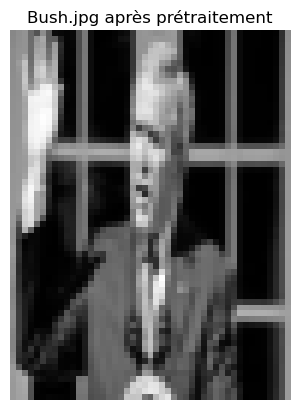

Statistiques de Bush.jpg après prétraitement : min=0.000, max=229.271, moyenne=67.825, std=60.434
Statistiques de Bush.jpg après normalisation : min=-7.304, max=2.793, moyenne=-1.940, std=2.091
Image Bush.jpg reconnue comme : George W Bush


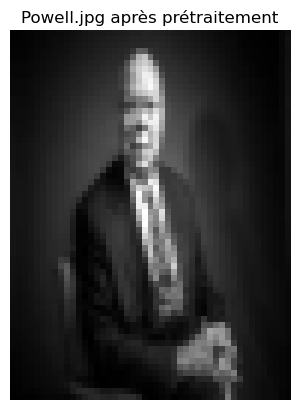

Statistiques de Powell.jpg après prétraitement : min=2.004, max=181.128, moyenne=30.500, std=29.934
Statistiques de Powell.jpg après normalisation : min=-5.897, max=1.327, moyenne=-2.938, std=1.252
Image Powell.jpg reconnue comme : Gerhard Schroeder


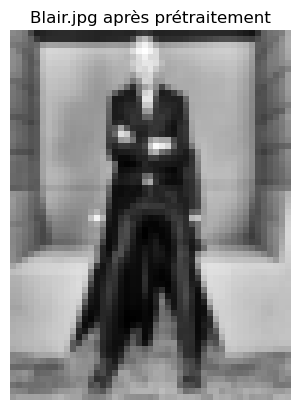

Statistiques de Blair.jpg après prétraitement : min=3.582, max=228.871, moyenne=112.980, std=54.327
Statistiques de Blair.jpg après normalisation : min=-6.358, max=2.699, moyenne=-0.638, std=1.717
Image Blair.jpg reconnue comme : Hugo Chavez


In [16]:
# Détermination du meilleur K (celui qui maximise le taux de reconnaissance)
K_opt = list(K_values)[int(np.argmax(accuracies))]
print(f"\nMeilleur K trouvé sur la base de test : {K_opt}")

# Entraînement du classifieur KNN une seule fois avec le meilleur K
knn_best = KNeighborsClassifier(n_neighbors=K_opt, metric='euclidean')
knn_best.fit(X_train_scaled, y_train)

# Chargement, prétraitement, affichage et prédiction pour chaque image web
for filename in ["Bush.jpg", "Powell.jpg", "Blair.jpg"]:
    I = Image.open(filename)
    I = np.array(I)
    # Conversion en niveaux de gris si besoin
    if I.ndim == 3:
        I = rgb2gray(I)
    # Redimensionnement si besoin (doit être 62x47)
    if I.shape != (62, 47):
        I = resize(I, (62, 47), anti_aliasing=True)
    # Conversion en float32 et remise à l'échelle 0-255 pour correspondre à la base
    I = I.astype(np.float32)
    if I.max() <= 1.0:
        I = I * 255.0
    # Affichage de l'image web après prétraitement
    plt.figure()
    plt.imshow(I, cmap='gray')
    plt.title(f"{filename} après prétraitement")
    plt.axis('off')
    plt.show()
    # Affichage des statistiques de l'image prétraitée
    print(f"Statistiques de {filename} après prétraitement : min={I.min():.3f}, max={I.max():.3f}, moyenne={I.mean():.3f}, std={I.std():.3f}")
    # Mise en forme comme pour les données d'apprentissage
    I_vect = I.reshape(1, -1)
    I_vect_scaled = scaler.transform(I_vect)
    # Affichage des statistiques après normalisation
    print(f"Statistiques de {filename} après normalisation : min={I_vect_scaled.min():.3f}, max={I_vect_scaled.max():.3f}, moyenne={I_vect_scaled.mean():.3f}, std={I_vect_scaled.std():.3f}")
    # Prédiction
    pred = knn_best.predict(I_vect_scaled)
    print(f"Image {filename} reconnue comme : {name[pred[0]]}")

##### Explication
Pour tester la reconnaissance sur des images du Web, on applique exactement le même prétraitement que pour les images de la base :
lecture, conversion en niveaux de gris, redimensionnement éventuel, vectorisation, normalisation avec le scaler appris sur le train.

On utilise le classifieur KPPV avec la valeur de K optimale trouvée précédemment.
Le résultat de la prédiction donne le nom de la personne reconnue pour chaque image testée.

## Conclusion

Dans ce TP, on a travaillé sur la reconnaissance de visages avec KPPV, à partir d’une vraie base d’images.

D’abord, on a regardé la base pour voir comment les classes étaient réparties. Ensuite, on a préparé les données : on les a découpées, mises en forme et normalisées. Après ça, on a entraîné un KNN et testé plusieurs valeurs de K pour choisir celle qui donnait le mieux.

Quand on a testé le modèle avec des images du web, certaines images sont bien reconnues. Mais pour d’autres, ça marche moins bien. On voit que ça dépend beaucoup du nombre d’exemples par classe : celles avec beaucoup d’images passent plus facilement, et celles avec peu d’images se mélangent plus souvent. Il faut donc assez d’exemples pour que le modèle apprenne correctement.

Ce TP montre aussi que le prétraitement est très important. Avec juste KNN sur des images brutes, on ne peut pas tout reconnaître correctement. Pour améliorer, il faudrait utiliser des descripteurs plus avancés ou des modèles capables d’extraire des caractéristiques plus discriminantes.

---

*Fin du compte rendu*